<a href="https://colab.research.google.com/github/jaydenhurt1215-dotcom/CS4410-HW/blob/main/JHurt_Extra_Credit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Bonus Assignment - Image Classification with MobileNetV2

I chose to use images of 3 different dog breeds.

In [29]:
import torch
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
from PIL import Image
import matplotlib.pyplot as plt
import requests
from io import BytesIO

In [30]:
weights = MobileNet_V2_Weights.DEFAULT
model = mobilenet_v2(weights=weights)
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print('Device:', device)

Device: cuda


In [31]:
preprocess = weights.transforms()
categories = weights.meta ['categories']

print('Number of classes:', len(categories))

Number of classes: 1000


Image 1 - Saluki

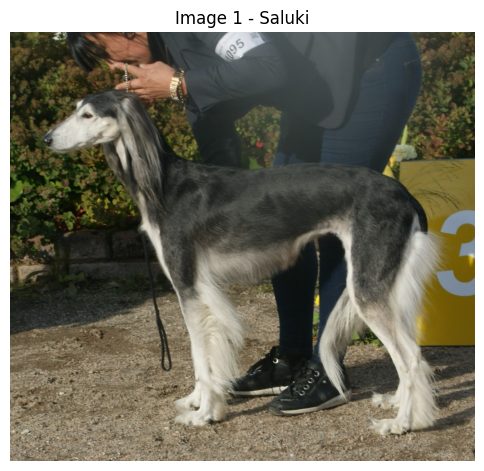

In [32]:
Saluki_url = "https://commons.wikimedia.org/wiki/Special:Redirect/file/Saluki_black_grizzle.jpg"

# User-Agent header for Wikimedia image request
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'}

response = requests.get(Saluki_url, headers=headers)
response.raise_for_status()

saluki_image = Image.open(BytesIO(response.content)).convert('RGB')

plt.figure(figsize=(6, 6))
plt.imshow(saluki_image)
plt.axis('off')
plt.title('Image 1 - Saluki')
plt.show()

In [33]:
input_tensor = preprocess(saluki_image).unsqueeze(0).to(device)
with torch.no_grad():
    output = model(input_tensor)

    probabilities = torch.nn.functional.softmax(output[0], dim=0)
    top5_prob, top5_catid = torch.topk(probabilities, 5)

    print('Top-5 predictions:')
    for i in range(5):
        print(f'{categories[top5_catid[i]]}: {top5_prob[i].item() * 100:.2f}%')

Top-5 predictions:
Saluki: 49.39%
borzoi: 15.60%
Afghan hound: 3.08%
whippet: 0.72%
Scottish deerhound: 0.71%


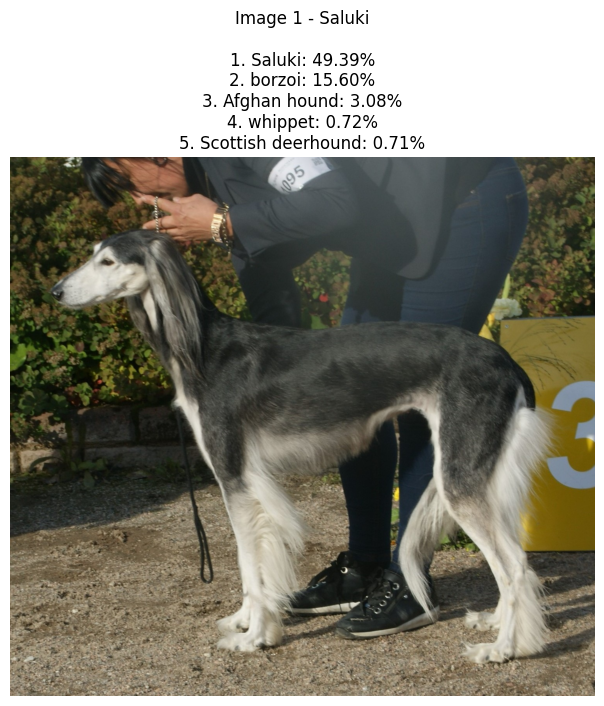

In [34]:
prediction_text = '\n'.join([f'{i+1}. {categories[top5_catid[i]]}: {top5_prob[i].item() * 100:.2f}%' for i in range(5)])

plt.figure(figsize=(8, 7))
plt.imshow(saluki_image)
plt.axis('off')
plt.title('Image 1 - Saluki\n\n' + prediction_text)
plt.show()

Image 2 - Belgian Laekenois

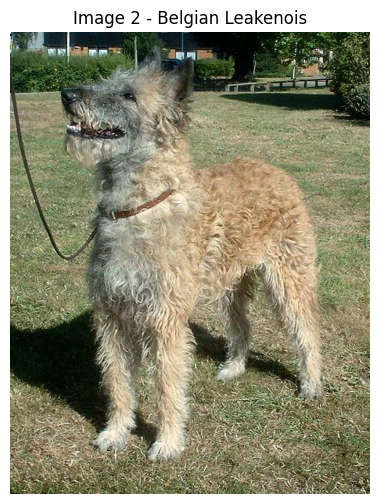

In [35]:
laekenois_url = "https://commons.wikimedia.org/wiki/Special:Redirect/file/Belgian_Laekenois_600.jpg"

# User-Agent header for Wikimedia image request
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'}

response = requests.get(laekenois_url, headers=headers)
response.raise_for_status()

laekenois_image = Image.open(BytesIO(response.content)).convert('RGB')

plt.figure(figsize=(6, 6))
plt.imshow(laekenois_image)
plt.axis('off')
plt.title('Image 2 - Belgian Leakenois')
plt.show()

In [36]:
input_tensor = preprocess(laekenois_image).unsqueeze(0).to(device)
with torch.no_grad():
    output = model(input_tensor)

    probabilities = torch.nn.functional.softmax(output[0], dim=0)
    top5_prob, top5_catid = torch.topk(probabilities, 5)

    print('Top-5 predictions:')
    for i in range(5):
        print(f'{categories[top5_catid[i]]}: {top5_prob[i].item() * 100:.2f}%')

Top-5 predictions:
Irish wolfhound: 21.13%
Scottish deerhound: 5.00%
soft-coated wheaten terrier: 3.45%
Irish terrier: 2.68%
Border terrier: 2.66%


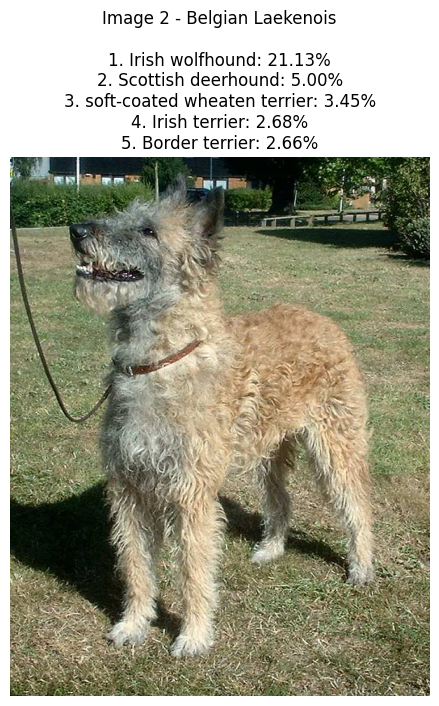

In [37]:
prediction_text = '\n'.join([f'{i+1}. {categories[top5_catid[i]]}: {top5_prob[i].item() * 100:.2f}%' for i in range(5)])

plt.figure(figsize=(8, 7))
plt.imshow(laekenois_image)
plt.axis('off')
plt.title('Image 2 - Belgian Laekenois\n\n' + prediction_text)
plt.show()

Image 3 - Irish Wolfhound

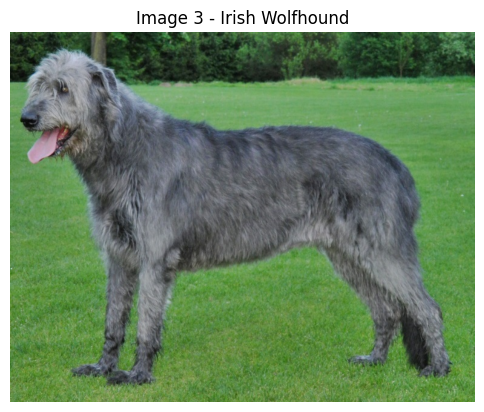

In [38]:
wolfhound_url ="https://commons.wikimedia.org/wiki/Special:Redirect/file/(2)_Irish_Wolfhound_4.jpg"

# User-Agent header for Wikimedia image request
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'}

response = requests.get(wolfhound_url, headers=headers)
response.raise_for_status()

wolfhound_image = Image.open(BytesIO(response.content)).convert('RGB')

plt.figure(figsize=(6, 6))
plt.imshow(wolfhound_image)
plt.axis('off')
plt.title('Image 3 - Irish Wolfhound')
plt.show()

In [39]:
input_tensor = preprocess(wolfhound_image).unsqueeze(0).to(device)
with torch.no_grad():
    output = model(input_tensor)

    probabilities = torch.nn.functional.softmax(output[0], dim=0)
    top5_prob, top5_catid = torch.topk(probabilities, 5)

    print('Top-5 predictions:')
    for i in range(5):
        print(f'{categories[top5_catid[i]]}: {top5_prob[i].item() * 100:.2f}%')

Top-5 predictions:
Scottish deerhound: 42.62%
Irish wolfhound: 21.15%
otterhound: 0.97%
Bouvier des Flandres: 0.81%
borzoi: 0.42%


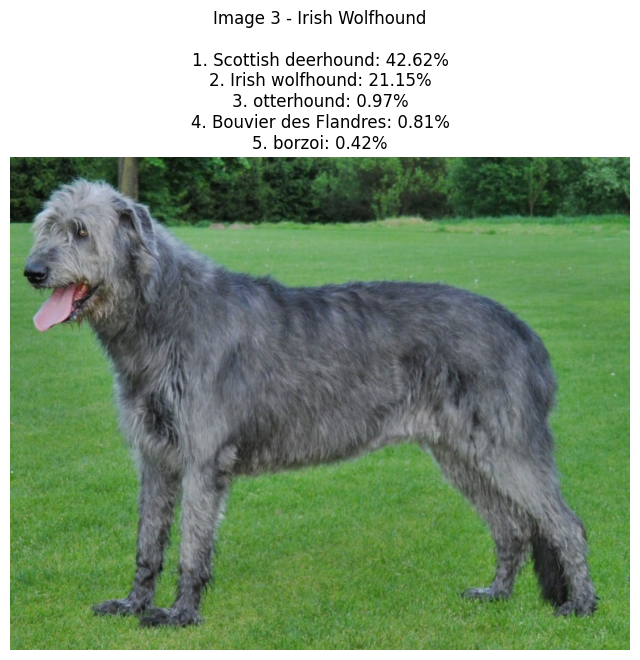

In [40]:
prediction_text = '\n'.join([f'{i+1}. {categories[top5_catid[i]]}: {top5_prob[i].item() * 100:.2f}%' for i in range(5)])

plt.figure(figsize=(8, 7))
plt.imshow(wolfhound_image)
plt.axis('off')
plt.title('Image 3 - Irish Wolfhound\n\n' + prediction_text)
plt.show()

MobileNetV2 did pretty well at recognizing the different dog breeds, but it was not always correct. It correctly identified the Saluki as its top prediction with 49.39% confidence. For the Belgian Laekenois, it predicted Irish Wolfhound as the top result with 21.13% confidence, and Belgian Laekenois did not appear in the top five predictions. For the Irish Wolfhound, it predicted Scottish Deerhound 1st with 42.62% confidence, while Irish Wolfhound came in 2nd with 21.15%. Overall, the model seemed to recognize similar features between the breeds even when it did not predict the correct breed.